<div style="font-size: 24px; line-height: 1.6;">

# Datasaurus: Same Stats, Different Shapes

## Why summary statistics are not enough

![Datasaurus: Same Stats, Different Shapes](../images/datasaurus_summary.png)

</div>

<div style="font-size: 24px; line-height: 1.6;">

## Takeaway

Functions featured: `groupby`, `.agg`, `corr`, `plot`.

**Concept learned: identical summary statistics can hide very different shapes — always plot.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

### Imports

</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (8, 5)

<div style="font-size: 24px; line-height: 1.6;">

## The story

The famous **Datasaurus Dozen** is 13 datasets engineered to share nearly the same mean, standard deviation, and correlation — yet each draws a completely different picture. If you trust the summary table alone, you never see the dinosaur. **Always plot.**

</div>

<div style="font-size: 24px; line-height: 1.6;">

## 1. Load the Datasaurus Dozen

</div>

In [2]:
dino = pd.read_csv("../data/datasaurus_dozen.csv")
dino.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


<div style="font-size: 24px; line-height: 1.6;">

## 2. The summary statistics look identical

</div>

In [3]:
dino.groupby("dataset")[["x", "y"]].agg(["mean", "std"]).round(2)

x             y       
             mean    std   mean    std
dataset                               
away        54.27  16.77  47.83  26.94
bullseye    54.27  16.77  47.83  26.94
circle      54.27  16.76  47.84  26.93
dino        54.26  16.77  47.83  26.94
dots        54.26  16.77  47.84  26.93
h_lines     54.26  16.77  47.83  26.94
high_lines  54.27  16.77  47.84  26.94
slant_down  54.27  16.77  47.84  26.94
slant_up    54.27  16.77  47.83  26.94
star        54.27  16.77  47.84  26.93
v_lines     54.27  16.77  47.84  26.94
wide_lines  54.27  16.77  47.83  26.94
x_shape     54.26  16.77  47.84  26.93

<div style="font-size: 24px; line-height: 1.6;">

Same mean, same standard deviation across all 13 sets.

</div>

<div style="font-size: 24px; line-height: 1.6;">

## 3. The correlation is identical too

</div>

In [4]:
dino.groupby("dataset")[["x", "y"]].corr().round(2)

x     y
dataset                 
away       x  1.00 -0.06
           y -0.06  1.00
bullseye   x  1.00 -0.07
           y -0.07  1.00
circle     x  1.00 -0.07
           y -0.07  1.00
dino       x  1.00 -0.06
           y -0.06  1.00
dots       x  1.00 -0.06
           y -0.06  1.00
h_lines    x  1.00 -0.06
           y -0.06  1.00
high_lines x  1.00 -0.07
           y -0.07  1.00
slant_down x  1.00 -0.07
           y -0.07  1.00
slant_up   x  1.00 -0.07
           y -0.07  1.00
star       x  1.00 -0.06
           y -0.06  1.00
v_lines    x  1.00 -0.07
           y -0.07  1.00
wide_lines x  1.00 -0.07
           y -0.07  1.00
x_shape    x  1.00 -0.07
           y -0.07  1.00

<div style="font-size: 24px; line-height: 1.6;">

## 4. Now plot them

</div>

<div style="font-size: 24px; line-height: 1.6;">

Same numbers, very different pictures:

</div>

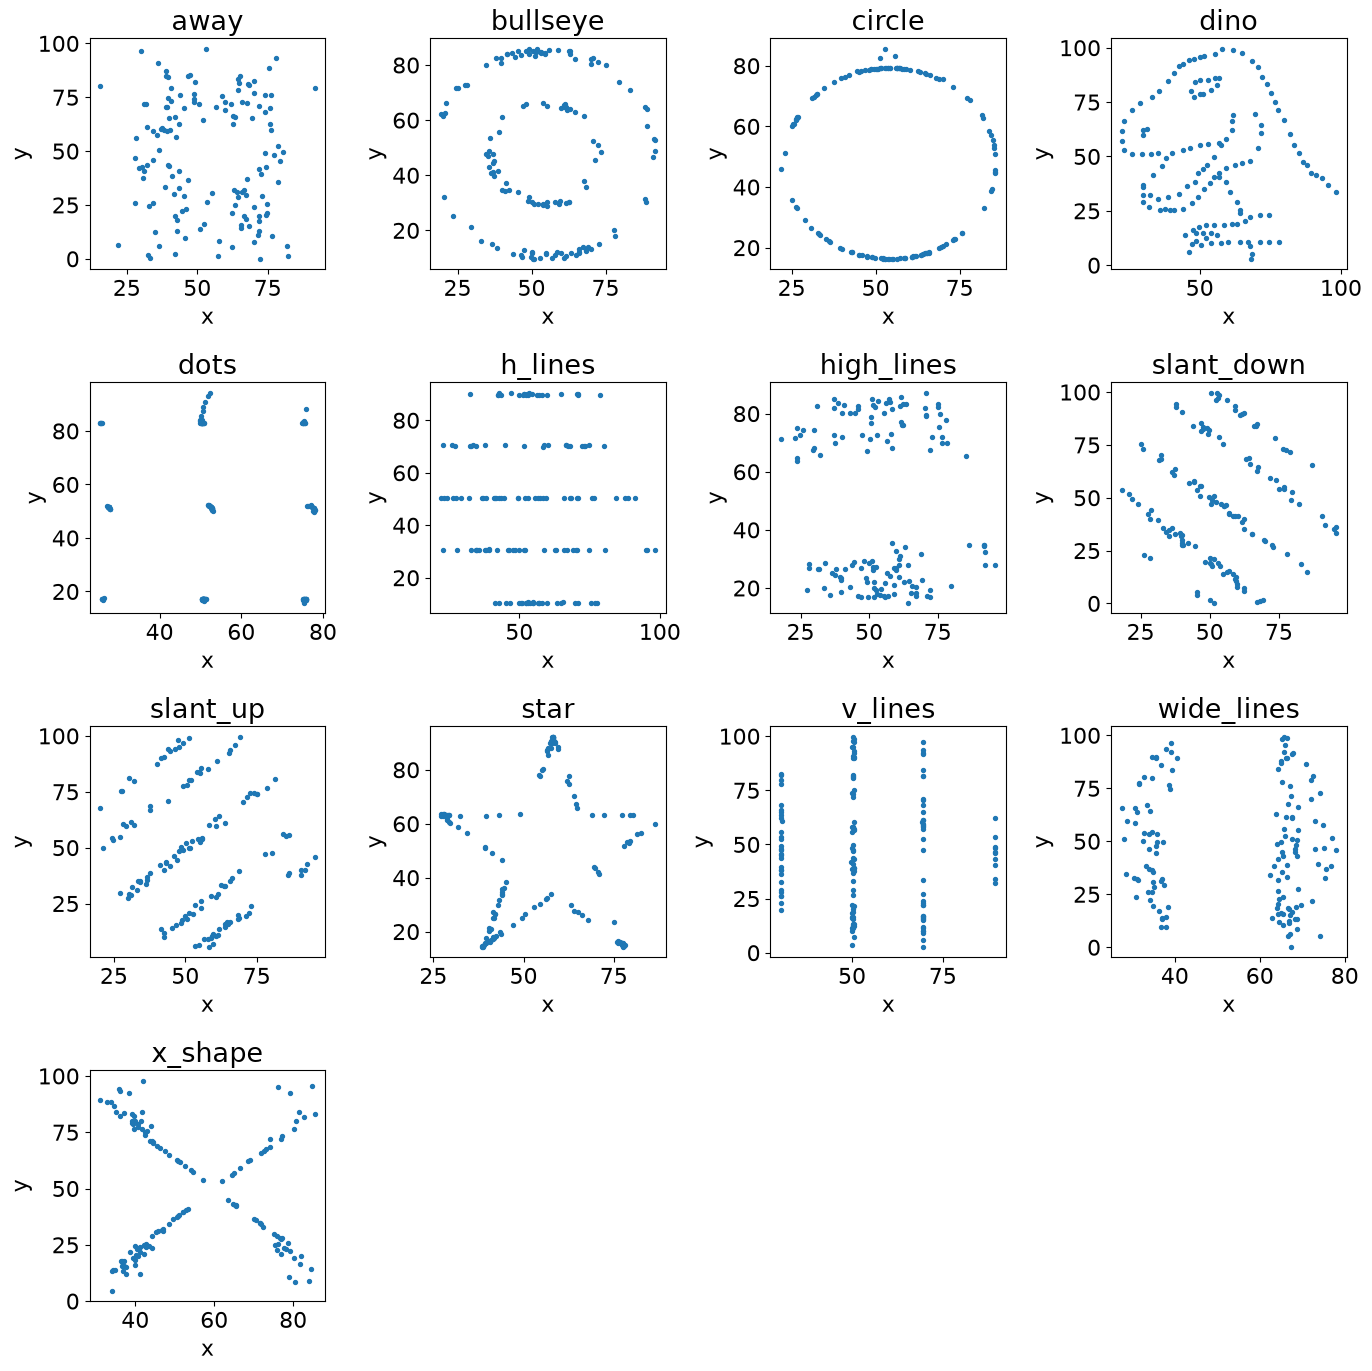

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for ax, (name, part) in zip(axes.flat, dino.groupby("dataset")):
    part.plot(kind="scatter", x="x", y="y", title=name, ax=ax, s=8)

# Hide the unused axes (13 datasets, 16 slots).
for ax in axes.flat[dino["dataset"].nunique():]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

<div style="font-size: 24px; line-height: 1.6;">

Identical means, standard deviations, and correlation — yet a dinosaur, a star, circles, and lines. **This is why you always plot the data.**

</div>